# Iris Flower Classification with Neural Networks

This notebook demonstrates how to build a neural network classifier to predict iris flower species.

In [215]:
import keras.optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np
import tensorflow as tf


## Data Loading and Preprocessing

Load Iris Dataset as pandas with column names, then convert it to numpy array and shuffle the data.

In [216]:
column_names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
df = pd.read_csv(url, names=column_names)

# Convert DataFrame to NumPy array and shuffle rows
data = df.values
np.random.shuffle(data)

Content of there iris dataset:

In [217]:
print(data)

[[6.5 2.8 4.6 1.5 'Iris-versicolor']
 [6.4 2.7 5.3 1.9 'Iris-virginica']
 [5.5 2.4 3.7 1.0 'Iris-versicolor']
 [6.0 2.7 5.1 1.6 'Iris-versicolor']
 [7.1 3.0 5.9 2.1 'Iris-virginica']
 [5.7 4.4 1.5 0.4 'Iris-setosa']
 [4.8 3.0 1.4 0.3 'Iris-setosa']
 [6.1 2.9 4.7 1.4 'Iris-versicolor']
 [4.9 3.1 1.5 0.1 'Iris-setosa']
 [4.5 2.3 1.3 0.3 'Iris-setosa']
 [6.5 3.0 5.8 2.2 'Iris-virginica']
 [5.1 2.5 3.0 1.1 'Iris-versicolor']
 [5.8 2.7 5.1 1.9 'Iris-virginica']
 [6.0 2.2 4.0 1.0 'Iris-versicolor']
 [6.1 3.0 4.6 1.4 'Iris-versicolor']
 [5.9 3.0 4.2 1.5 'Iris-versicolor']
 [6.3 3.3 4.7 1.6 'Iris-versicolor']
 [6.3 2.9 5.6 1.8 'Iris-virginica']
 [5.5 4.2 1.4 0.2 'Iris-setosa']
 [7.7 2.6 6.9 2.3 'Iris-virginica']
 [4.9 2.4 3.3 1.0 'Iris-versicolor']
 [4.8 3.4 1.9 0.2 'Iris-setosa']
 [7.2 3.0 5.8 1.6 'Iris-virginica']
 [5.7 2.8 4.1 1.3 'Iris-versicolor']
 [7.7 3.8 6.7 2.2 'Iris-virginica']
 [5.4 3.4 1.5 0.4 'Iris-setosa']
 [7.7 3.0 6.1 2.3 'Iris-virginica']
 [4.6 3.1 1.5 0.2 'Iris-setosa']
 [5.7

In [218]:
data.shape

(150, 5)

Split the dataset into feature and target variables, where X contains everything other than the last column and y contains only the last column.

In [219]:
X = data[:, :-1]
y = data[:, -1]

In [220]:
X.shape

(150, 4)

In [221]:
y.shape

(150,)

Standardize the feature variables and convert categorical target labels to numerical values and also use to_categorical to one hot encode y variable.

In [222]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

y = to_categorical(y, num_classes=3)

## Model Architecture


- **Input Layer**: Here a simple neural network with an input layer that takes 4 features (sepal length, sepal width, petal length, petal width). 
- **Hidden Layer**: Then there is one Hidden Layer with 13 neurons with ReLU activation
- **Output Layer**: Output Layer with 3 neurons and softmax activation which ensures outputs sum to 1.

In [223]:
from keras.optimizers import RMSprop

model = Sequential([
    Dense(13, activation='relu', input_shape=(4,)),
    Dense(3, activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


## Model Training

Here, the model is trained with:
- **100 epochs**: Maximum number of complete passes through the training dataset
- **Batch size of 10**: Number of samples processed before the model weights are updated
- **Validation split of 20%**: Reserves 20% of the data for validation
- **Early Stopping**: Prevent overfitting by stopping training when the model's performance on the validation set stops improving


In [224]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(X, y, epochs=100, validation_split=0.2, batch_size=10, callbacks=[early_stopping])

Epoch 1/100
12/12 [==============================] - 0s 4ms/step - loss: 1.2127 - accuracy: 0.3167 - val_loss: 1.1005 - val_accuracy: 0.3667
Epoch 2/100
12/12 [==============================] - 0s 1ms/step - loss: 1.1183 - accuracy: 0.3167 - val_loss: 1.0308 - val_accuracy: 0.3667
Epoch 3/100
12/12 [==============================] - 0s 967us/step - loss: 1.0365 - accuracy: 0.3167 - val_loss: 0.9688 - val_accuracy: 0.3667
Epoch 4/100
12/12 [==============================] - 0s 942us/step - loss: 0.9654 - accuracy: 0.3500 - val_loss: 0.9143 - val_accuracy: 0.4333
Epoch 5/100
12/12 [==============================] - 0s 946us/step - loss: 0.8974 - accuracy: 0.3917 - val_loss: 0.8675 - val_accuracy: 0.5333
Epoch 6/100
12/12 [==============================] - 0s 982us/step - loss: 0.8428 - accuracy: 0.5583 - val_loss: 0.8250 - val_accuracy: 0.6667
Epoch 7/100
12/12 [==============================] - 0s 1ms/step - loss: 0.7905 - accuracy: 0.7083 - val_loss: 0.7879 - val_accuracy: 0.7000
Epoch

Here is a visualization of the model's training loss and validation loss are decreasing evenly and don't start increasing or plateauing which would mean that the model is overfitting.

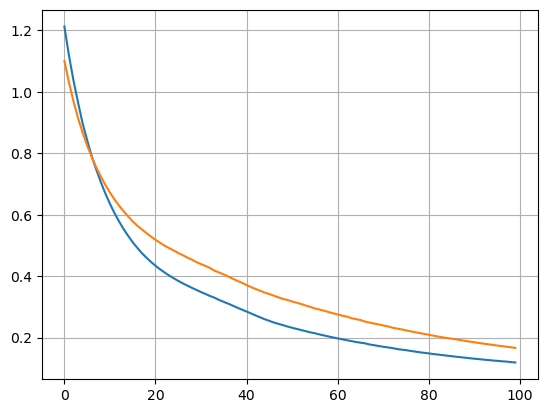

In [225]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

### Model Evaluation
Here we can see that the models test loss score is 0.128 and the test accuracy is about 0.97.

In [226]:
test_scores = model.evaluate(X, y, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

5/5 - 0s - loss: 0.1281 - accuracy: 0.9667 - 35ms/epoch - 7ms/step
Test loss: 0.12805399298667908
Test accuracy: 0.9666666388511658
